In [454]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import time
from torch import nn
from sklearn.metrics import r2_score

In [455]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tensor([[0.0000],
        [0.0500],
        [0.1000],
        [0.1500],
        [0.2000],
        [0.2500],
        [0.3000],
        [0.3500],
        [0.4000],
        [0.4500]]) tensor([[ 9.3710],
        [13.4633],
        [13.3791],
        [11.5346],
        [16.4192],
        [10.1464],
        [16.4557],
        [12.4137],
        [ 9.8661],
        [15.5626]])


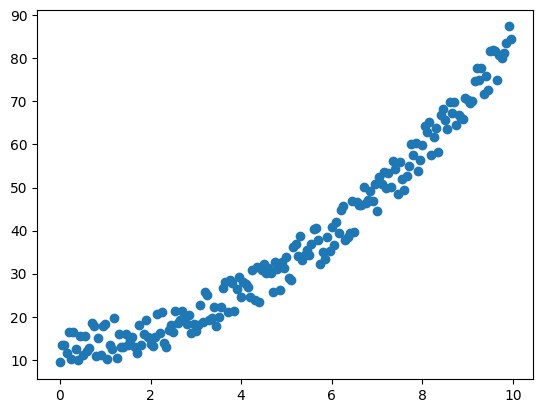

In [456]:
weight = 0.7
bias = 9

X = torch.arange(start=0, end=10, step=0.05).unsqueeze(dim=1)
y = weight * X**2 + bias
nois = torch.rand_like(y) * 10
y += nois

print(X[:10],y[:10])
plt.scatter(X, y)

In [457]:
X = (X - X.mean()) / X.std()

In [458]:
df = pd.DataFrame({"X": X.flatten().numpy(), "y": y.flatten().numpy()})
data = df.sample(frac=1).reset_index(drop=True)

X = torch.tensor(data["X"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(data["y"].values, dtype=torch.float32).unsqueeze(1)

In [459]:
split = int(len(X) * 0.7)

X_train, y_train = X[: split], y[: split]
X_test, y_test = X[split :], y[split :]

len(X_train), len(y_train), len(X_test), len(y_test), 

(140, 140, 60, 60)

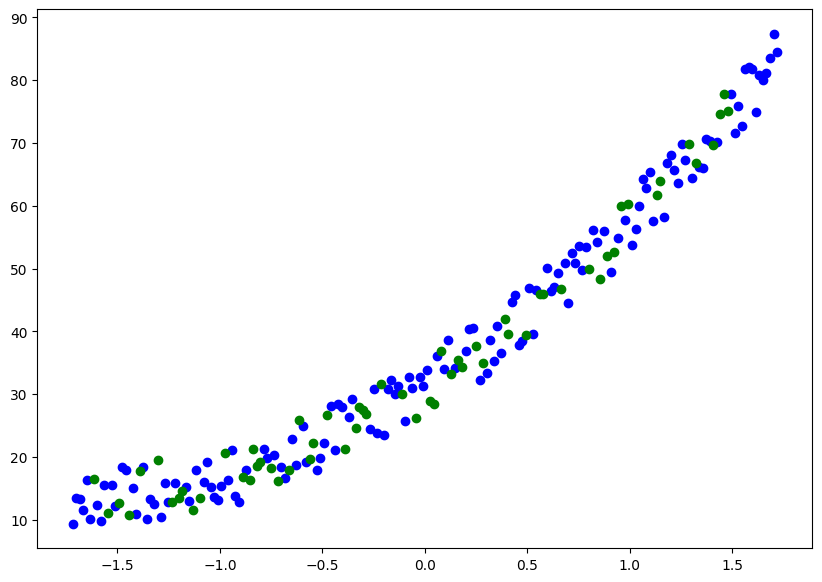

In [460]:
def plot(train_data=X_train,
         train_labels=y_train,
         test_data=X_test,
         test_labels=y_test,
         predictions=None):

    plt.figure(figsize=(10,7))

    plt.scatter(train_data.cpu(), train_labels.cpu(), c="blue")
    plt.scatter(test_data.cpu(), test_labels.cpu(), c="green")

    if predictions is not None:
        plt.scatter(test_data.cpu(), predictions, c="red")

    plt.show()
    
plot()

In [461]:
import torch.nn as nn
import torch.nn.functional as F

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.Layer1 = nn.Linear(in_features=1, out_features=40)
        self.Layer2 = nn.Linear(in_features=40, out_features=1)
        self.activation = nn.ReLU()
        
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        x = self.Layer1(X)
        x = self.activation(x)
        x = self.Layer2(x)
        return x

In [462]:
model_0 = LinearRegression()
model_0.state_dict()

OrderedDict([('Layer1.weight',
              tensor([[-0.6350],
                      [ 0.9208],
                      [-0.9822],
                      [-0.7716],
                      [-0.4067],
                      [-0.3689],
                      [-0.2005],
                      [-0.3727],
                      [ 0.0892],
                      [ 0.0210],
                      [-0.9117],
                      [-0.7860],
                      [-0.0664],
                      [-0.1765],
                      [ 0.6457],
                      [-0.2493],
                      [-0.0146],
                      [ 0.8529],
                      [-0.3072],
                      [ 0.4032],
                      [ 0.5718],
                      [-0.7925],
                      [ 0.4793],
                      [-0.2608],
                      [ 0.9962],
                      [ 0.1167],
                      [-0.4562],
                      [ 0.6374],
                      [ 0.2557],
            

In [463]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

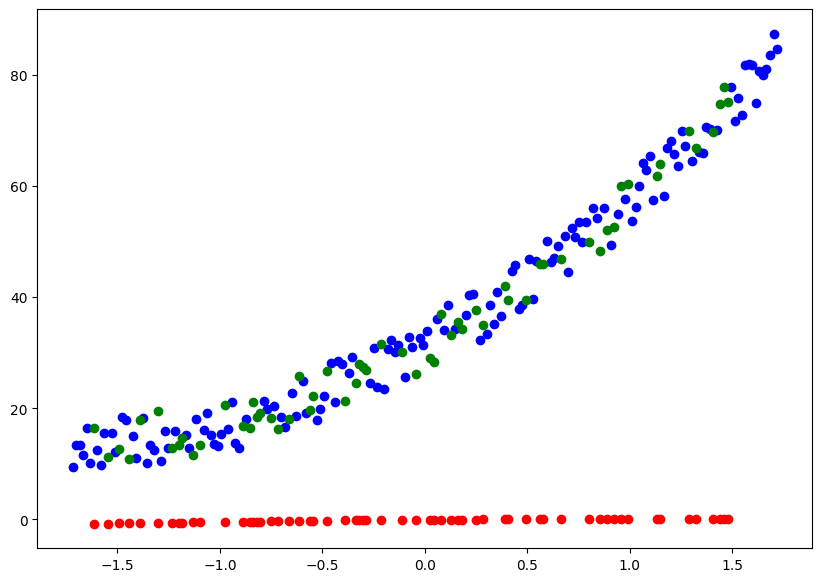

In [464]:
plot(predictions=y_preds)

In [465]:
torch.manual_seed(47)

model_0 = LinearRegression().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adadelta(model_0.parameters(), lr=0.5)

In [466]:
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

In [467]:
torch.manual_seed(47)

epochs = 900

train_loss_values = []
test_loss_values = []
train_r2_values = []
test_r2_values = []
epoch_count = []

for epoch in range(epochs):
    # Set to train mode
    model_0.train()
    
    # Forward pass
    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate R² for training (regression metric)
    with torch.no_grad():
        train_r2 = r2_score(y_train.cpu().numpy(), y_pred.cpu().numpy())
    
    # Test mode
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)
        test_r2 = r2_score(y_test.cpu().numpy(), test_pred.cpu().numpy())
    
    # Store values
    epoch_count.append(epoch)
    train_loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())
    train_r2_values.append(train_r2)
    test_r2_values.append(test_r2)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")


Epoch: 0 | Train Loss: 1981.1678 | Test Loss: 1505.1282 | Train R²: -2.9960 | Test R²: -3.2316
Epoch: 10 | Train Loss: 1964.9784 | Test Loss: 1491.3857 | Train R²: -2.9633 | Test R²: -3.1929
Epoch: 20 | Train Loss: 1943.9607 | Test Loss: 1473.6780 | Train R²: -2.9209 | Test R²: -3.1431
Epoch: 30 | Train Loss: 1854.3235 | Test Loss: 1394.9043 | Train R²: -2.7401 | Test R²: -2.9217
Epoch: 40 | Train Loss: 1274.4105 | Test Loss: 899.1616 | Train R²: -1.5705 | Test R²: -1.5279
Epoch: 50 | Train Loss: 205.7583 | Test Loss: 126.1840 | Train R²: 0.5850 | Test R²: 0.6452
Epoch: 60 | Train Loss: 39.2591 | Test Loss: 37.0799 | Train R²: 0.9208 | Test R²: 0.8958
Epoch: 70 | Train Loss: 31.9039 | Test Loss: 30.3038 | Train R²: 0.9357 | Test R²: 0.9148
Epoch: 80 | Train Loss: 27.9304 | Test Loss: 26.0835 | Train R²: 0.9437 | Test R²: 0.9267
Epoch: 90 | Train Loss: 25.2776 | Test Loss: 23.5836 | Train R²: 0.9490 | Test R²: 0.9337
Epoch: 100 | Train Loss: 23.3557 | Test Loss: 21.9100 | Train R²: 0.95

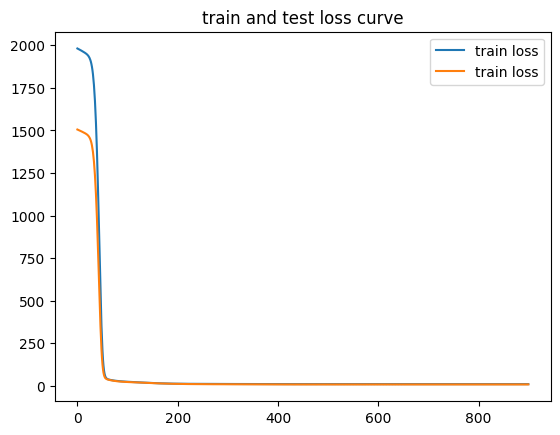

In [468]:
plt.title("train and test loss curve")
plt.plot(epoch_count, train_loss_values, label="train loss")
plt.plot(epoch_count, test_loss_values, label="train loss")
plt.legend()

In [469]:
model_0.state_dict()

OrderedDict([('Layer1.weight',
              tensor([[-0.9454],
                      [-1.0075],
                      [-0.2827],
                      [ 1.4109],
                      [ 0.1121],
                      [ 1.5128],
                      [ 1.6442],
                      [-0.8896],
                      [-0.7900],
                      [-0.1310],
                      [ 3.2971],
                      [ 1.5598],
                      [-0.8323],
                      [-0.6601],
                      [-0.6751],
                      [-0.7305],
                      [ 1.8299],
                      [-1.2123],
                      [-1.1217],
                      [-0.5389],
                      [ 0.0681],
                      [ 0.4268],
                      [-1.2964],
                      [-0.5727],
                      [-0.7715],
                      [ 0.4643],
                      [ 1.4336],
                      [ 0.0611],
                      [-2.8340],
            

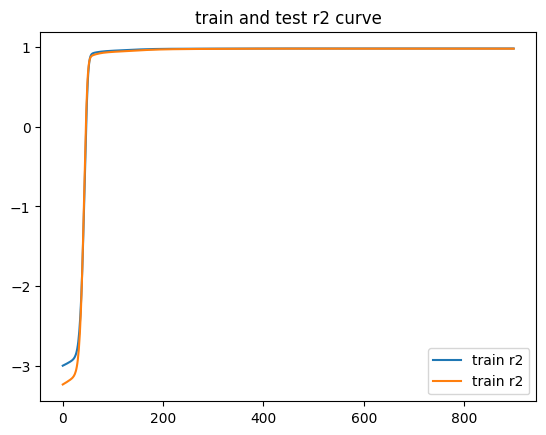

In [470]:
plt.title("train and test r2 curve")
plt.plot(epoch_count, train_r2_values, label="train r2")
plt.plot(epoch_count, test_r2_values, label="train r2")
plt.legend()

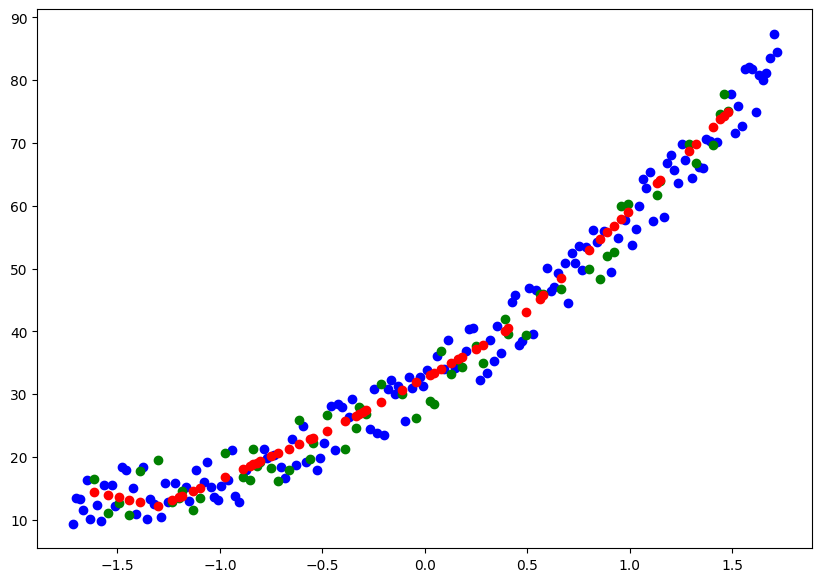

In [471]:
plot(predictions=test_pred.detach().cpu().numpy())